## happy family time
# สมาชิกในกลุ่ม
- นายธีรวัต แซ่น่ำ - 6810110163
- นายฟุรกร ซำซี - 6810110664
- นายซัซวาลย์ บินสะอิ - 6810110066
- อัลฟารุก ช่างเรือ - 6810110421



In [14]:
# matplotlib inline
import ast
import csv
from pathlib import Path
import matplotlib.pyplot as plt

# กำหนด path ต่างๆ ของโปรเจกต์
analysis_dir = Path.cwd()
if not (analysis_dir / 'plots').exists() and (analysis_dir / 'analysis').exists():
    analysis_dir = analysis_dir / 'analysis'

project_root = analysis_dir.parent
data_raw_dir = project_root / 'data' / 'raw'
plots_dir = analysis_dir / 'plots'

# ค้นหา run folder ทั้งหมดที่มีใน data/raw
run_dirs = sorted([d for d in data_raw_dir.iterdir() if d.is_dir() and d.name.startswith('run')])

# เลือก run เริ่มต้นที่จะแสดงผลใน notebook (ค่าเริ่มต้นเป็น run แรกที่เจอ)
selected_run = 'run1'
if run_dirs:
    selected_run = run_dirs[0].name

run_dir = data_raw_dir / selected_run

def find_csv_file(run_path, pattern):
    """
    ค้นหาไฟล์ CSV ที่ตรงกับรูปแบบที่กำหนดใน run folder
    """
    files = list(run_path.glob(pattern))
    if files:
        return files[0]
    return None

def read_csv(path):
    with open(path, newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

def plot_series(title, x, series, labels, ylabel, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    for y, label in zip(series, labels):
        ax.plot(x, y, label=label)
    ax.set_title(title)
    ax.set_xlabel('relative_time (s)')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close(fig)


## 1. กราฟ Attitude สามารถบอกค่า Yaw , pich , roll ได้


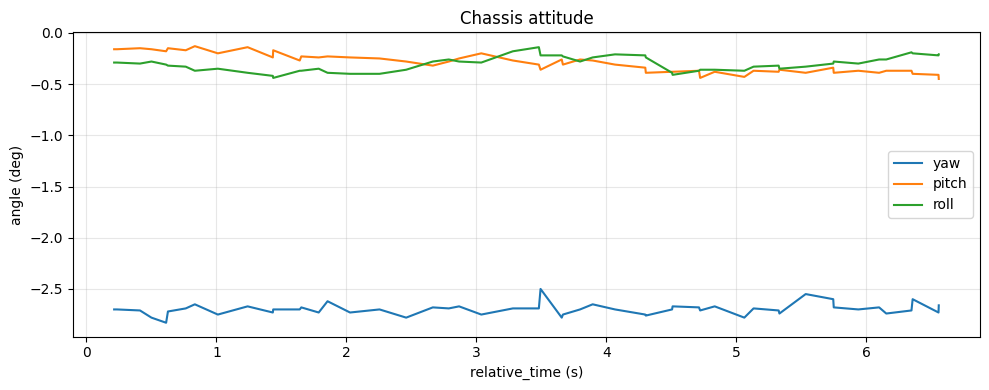

In [9]:
# 1) Attitude
attitude_file = find_csv_file(run_dir, "*attitude.csv")
if attitude_file:
    print(f"Reading attitude from {attitude_file.name} ({selected_run})")
    attitude = read_csv(attitude_file)
    t = [float(r['relative_time']) for r in attitude]
    yaw = [float(r['yaw']) for r in attitude]
    pitch = [float(r['pitch']) for r in attitude]
    roll = [float(r['roll']) for r in attitude]
    save_path = plots_dir / selected_run / 'attitude.png'
    plot_series('Chassis attitude', t, [yaw, pitch, roll], ['yaw', 'pitch', 'roll'], 'angle (deg)', save_path=save_path)
else:
    print(f"ไม่พบไฟล์ attitude ใน {selected_run}")


## 2. กราฟ ESC motor speeds หรือกราฟที่จะบอกค่าการทำงานของมอเตอร์แต่ละตัว

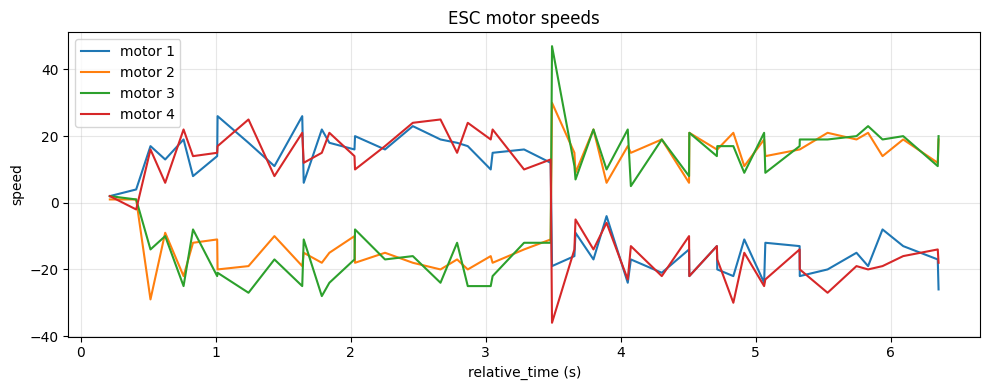

In [10]:
# 2) ESC speed
esc_file = find_csv_file(run_dir, "*esc.csv")
if esc_file:
    print(f"Reading ESC speed from {esc_file.name} ({selected_run})")
    esc_data = read_csv(esc_file)
    t = [float(r['relative_time']) for r in esc_data]
    raw_speeds = [ast.literal_eval(r['esc_speed']) for r in esc_data]
    motor_series = list(zip(*raw_speeds))
    save_path = plots_dir / selected_run / 'motor_speeds.png'
    plot_series('ESC motor speeds', t, motor_series, ['motor 1', 'motor 2', 'motor 3', 'motor 4'], 'speed (rpm)', save_path=save_path)
else:
    print(f"ไม่พบไฟล์ ESC speed ใน {selected_run}")


## 3. กราฟ IMU 

ในกราฟที่ 1 สามารถวัดความเร็วเชิงมุมของหุ่นยนต์

ส่วนกราฟที่ 2 สามารถวัดอัตตราการหมุนของหุ่นยนต์

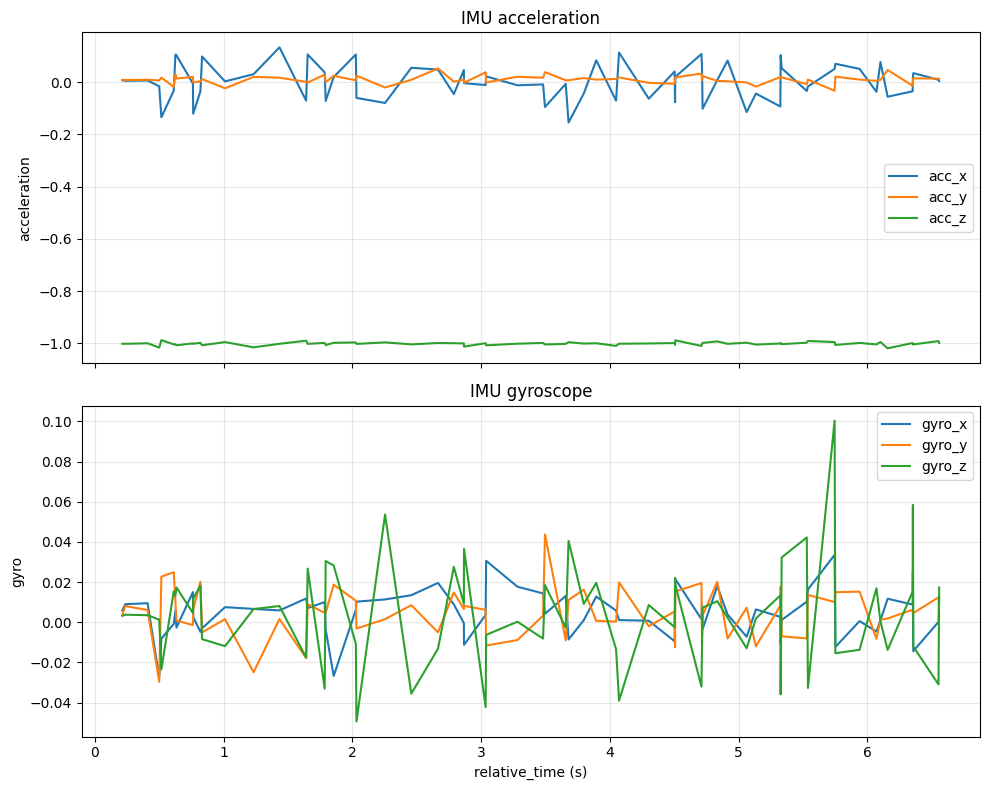

In [11]:
# 3) IMU
imu_file = find_csv_file(run_dir, "*imu.csv")
if imu_file:
    print(f"Reading IMU from {imu_file.name} ({selected_run})")
    imu_data = read_csv(imu_file)
    t = [float(r['relative_time']) for r in imu_data]
    acc_x = [float(r['acc_x']) for r in imu_data]
    acc_y = [float(r['acc_y']) for r in imu_data]
    acc_z = [float(r['acc_z']) for r in imu_data]
    gyro_x = [float(r['gyro_x']) for r in imu_data]
    gyro_y = [float(r['gyro_y']) for r in imu_data]
    gyro_z = [float(r['gyro_z']) for r in imu_data]

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(t, acc_x, label='acc_x')
    axes[0].plot(t, acc_y, label='acc_y')
    axes[0].plot(t, acc_z, label='acc_z')
    axes[0].set_title('IMU acceleration')
    axes[0].set_ylabel('acceleration (g)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, gyro_x, label='gyro_x')
    axes[1].plot(t, gyro_y, label='gyro_y')
    axes[1].plot(t, gyro_z, label='gyro_z')
    axes[1].set_title('IMU gyroscope')
    axes[1].set_xlabel('relative_time (s)')
    axes[1].set_ylabel('gyro (deg/s)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_path = plots_dir / selected_run / 'imu.png'
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close(fig)
else:
    print(f"ไม่พบไฟล์ IMU ใน {selected_run}")


## 4. กราฟวัดตำแหน่งจากจุดเริ่มต้นของตัวหุ่นยนต์

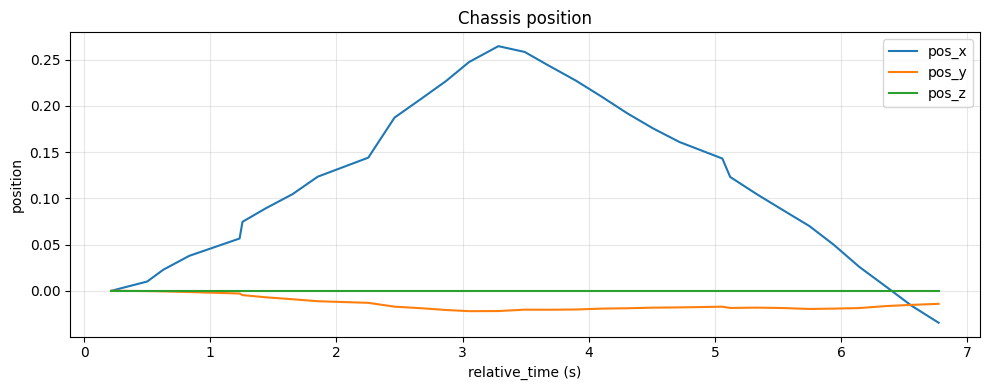

In [12]:
# 4) Position
position_file = find_csv_file(run_dir, "*position.csv")
if position_file:
    print(f"Reading position from {position_file.name} ({selected_run})")
    position = read_csv(position_file)
    t = [float(r['relative_time']) for r in position]
    pos_x = [float(r['pos_x']) for r in position]
    pos_y = [float(r['pos_y']) for r in position]
    pos_z = [float(r['pos_z']) for r in position]
    save_path = plots_dir / selected_run / 'position.png'
    plot_series('Chassis position', t, [pos_x, pos_y, pos_z], ['pos_x', 'pos_y', 'pos_z'], 'position (m)', save_path=save_path)
else:
    print(f"ไม่พบไฟล์ position ใน {selected_run}")


## 5. กราฟบอกสถานะของหุ่น

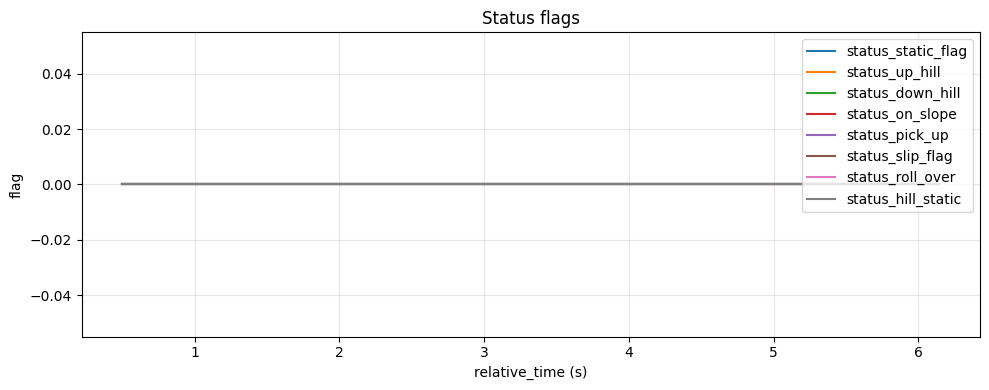

In [13]:
# 5) Status flags
status_file = find_csv_file(run_dir, "*status.csv")
if status_file:
    print(f"Reading status from {status_file.name} ({selected_run})")
    status = read_csv(status_file)
    t = [float(r['relative_time']) for r in status]
    status_cols = [
        'status_static_flag', 'status_up_hill', 'status_down_hill', 'status_on_slope',
        'status_pick_up', 'status_slip_flag', 'status_roll_over', 'status_hill_static'
    ]
    series = []
    for col in status_cols:
        series.append([int(float(r[col])) for r in status])
    save_path = plots_dir / selected_run / 'status.png'
    plot_series('Status flags', t, series, status_cols, 'flag (0/1)', save_path=save_path)
else:
    print(f"ไม่พบไฟล์ status ใน {selected_run}")


## 6. บันทึกรูปภาพทุกกราฟสำหรับทุก Run โดยอัตโนมัติ (Batch Plotting & Saving)

In [ ]:
# โค้ดสำหรับรันการวิเคราะห์และบันทึกภาพสำหรับทุก Run ใน data/raw
if not run_dirs:
    print("ไม่พบโฟลเดอร์ Run ใดๆ ใน data/raw/")
else:
    for r_dir in run_dirs:
        r_name = r_dir.name
        print(f"========================================")
        print(f"กำลังประมวลผลข้อมูลและบันทึกกราฟสำหรับ: {r_name}")
        print(f"========================================")
        r_plots_dir = plots_dir / r_name
        r_plots_dir.mkdir(parents=True, exist_ok=True)
        
        # 1) Attitude
        f = find_csv_file(r_dir, "*attitude.csv")
        if f:
            data = read_csv(f)
            t = [float(r['relative_time']) for r in data]
            plot_series('Chassis attitude', t, 
                        [[float(r['yaw']) for r in data], [float(r['pitch']) for r in data], [float(r['roll']) for r in data]], 
                        ['yaw', 'pitch', 'roll'], 'angle (deg)', save_path=r_plots_dir / 'attitude.png')
        else:
            print(f"  - ข้าม Attitude (ไม่พบไฟล์)")
                        
        # 2) ESC speed
        f = find_csv_file(r_dir, "*esc.csv")
        if f:
            data = read_csv(f)
            t = [float(r['relative_time']) for r in data]
            raw_speeds = [ast.literal_eval(r['esc_speed']) for r in data]
            motor_series = list(zip(*raw_speeds))
            plot_series('ESC motor speeds', t, motor_series, 
                        ['motor 1', 'motor 2', 'motor 3', 'motor 4'], 'speed (rpm)', save_path=r_plots_dir / 'motor_speeds.png')
        else:
            print(f"  - ข้าม ESC speed (ไม่พบไฟล์)")
                        
        # 3) IMU
        f = find_csv_file(r_dir, "*imu.csv")
        if f:
            data = read_csv(f)
            t = [float(r['relative_time']) for r in data]
            fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
            axes[0].plot(t, [float(r['acc_x']) for r in data], label='acc_x')
            axes[0].plot(t, [float(r['acc_y']) for r in data], label='acc_y')
            axes[0].plot(t, [float(r['acc_z']) for r in data], label='acc_z')
            axes[0].set_title('IMU acceleration')
            axes[0].set_ylabel('acceleration (g)')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            axes[1].plot(t, [float(r['gyro_x']) for r in data], label='gyro_x')
            axes[1].plot(t, [float(r['gyro_y']) for r in data], label='gyro_y')
            axes[1].plot(t, [float(r['gyro_z']) for r in data], label='gyro_z')
            axes[1].set_title('IMU gyroscope')
            axes[1].set_xlabel('relative_time (s)')
            axes[1].set_ylabel('gyro (deg/s)')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(r_plots_dir / 'imu.png', dpi=300)
            plt.show()
            plt.close(fig)
        else:
            print(f"  - ข้าม IMU (ไม่พบไฟล์)")
            
        # 4) Position
        f = find_csv_file(r_dir, "*position.csv")
        if f:
            data = read_csv(f)
            t = [float(r['relative_time']) for r in data]
            plot_series('Chassis position', t, 
                        [[float(r['pos_x']) for r in data], [float(r['pos_y']) for r in data], [float(r['pos_z']) for r in data]], 
                        ['pos_x', 'pos_y', 'pos_z'], 'position (m)', save_path=r_plots_dir / 'position.png')
        else:
            print(f"  - ข้าม Position (ไม่พบไฟล์)")
                        
        # 5) Status flags
        f = find_csv_file(r_dir, "*status.csv")
        if f:
            data = read_csv(f)
            t = [float(r['relative_time']) for r in data]
            status_cols = [
                'status_static_flag', 'status_up_hill', 'status_down_hill', 'status_on_slope',
                'status_pick_up', 'status_slip_flag', 'status_roll_over', 'status_hill_static'
            ]
            series = []
            for col in status_cols:
                series.append([int(float(r[col])) for r in data])
            plot_series('Status flags', t, series, status_cols, 'flag (0/1)', save_path=r_plots_dir / 'status.png')
        else:
            print(f"  - ข้าม Status flags (ไม่พบไฟล์)")
        print(f"เสร็จสิ้นการบันทึกภาพสำหรับ: {r_name}\n")
